# Behavioral Performance

Reproduces behavioral results from the paper:
- **Figure 10**: Held-out accuracy for cyclic and dihedral groups (Appendix C.3)
- **Figure 11**: Train and held-out accuracy for OOD algebraic structures (Appendix C.3)
- **Figure 12**: Quasigroup cancellation performance (Appendix C.3)
- **Figure 3c / Table 2**: Model performance on targeted distributions

In [1]:
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import nnsight

from sympy.combinatorics import CyclicGroup, DihedralGroup, PermutationGroup, Permutation
from sympy.combinatorics.group_constructs import DirectProduct
from src.tasks.magma import Magma, Quasigroup
from src.data_utils import sample_distribution_batch
from src.load_utils import load_gpt, load_task
from IPython.display import HTML

In [2]:
dirname = '../outputs/mixrosette-facts-10-16-8heads'

gpt = load_gpt(dirname).cuda()
test_task, task_name = load_task(dirname)
model = nnsight.NNsight(gpt)

number of parameters: 50.42M
iteration: inf
Trained on mixrosette up to order 10 with 16 symbols


In [3]:
# Publication-quality plot defaults
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.major.width'] = 0.8
plt.rcParams['ytick.major.width'] = 0.8
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['legend.fancybox'] = False

In [4]:
def sequential_accuracy(model, task, **kwargs):
    """Compute accuracy over all prediction positions for a batch at fixed k_shots."""
    device = next(model.parameters()).device
    with torch.no_grad():
        batch = task.sample_batch(**kwargs)
        outputs = model(batch['inputs'].to(device))[0]
        targets = batch['targets']
        predictions = outputs.argmax(2).cpu()
        # Assume all the inputs have the same format as the 0th
        mask = batch['inputs'][0] == task.predict_token_id
        accuracy = (predictions[:,mask] == targets[:,mask]).float().mean(0)
    return accuracy

def held_out_accuracy(model, task, **kwargs):
    """Compute held-out accuracy on the final fact as a function of number of in-context facts."""
    device = next(model.parameters()).device
    accuracies = []
    for shots in tqdm(range(5, 200)):
        with torch.no_grad():
            batch = task.sample_batch(k_shots=shots, **kwargs)
            outputs = model(batch['inputs'].to(device))
            targets = batch['targets']
            if not isinstance(outputs, torch.Tensor):
                outputs = outputs[0]
            predictions = outputs.argmax(2).cpu()
            accuracy = (predictions[:,-1] == targets[:,-1]).float().mean(0).item()
        accuracies.append((shots, accuracy))
    return list(zip(*accuracies))

## Cyclic and Dihedral Groups (Figure 10)

In [5]:
c_values = range(3, 11)
d_values = [3, 4, 5]

heldout_scores = {}

for m in c_values:
    heldout_scores[f'cyclic_{m}'] = held_out_accuracy(
        model, test_task, batch_size=400, fixed_groups=[CyclicGroup(m)], hold_out=True
    )

for m in d_values:
    heldout_scores[f'dihedral_{m}'] = held_out_accuracy(
        model, test_task, batch_size=400, fixed_groups=[DihedralGroup(m)], hold_out=True
    )

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

...

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

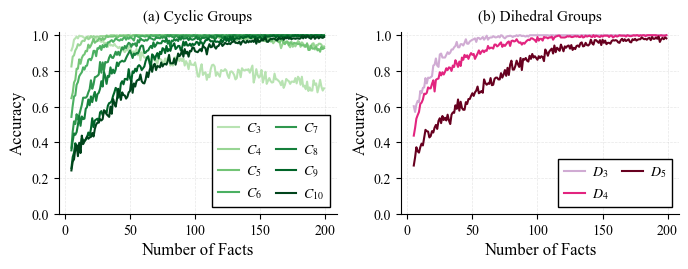

In [25]:
cyclic_colors = [plt.cm.Greens(0.3 + 0.7 * i / (len(c_values) - 1)) for i in range(len(c_values))]
dihedral_colors = [plt.cm.PuRd(0.3 + 0.7 * i / (len(d_values) - 1)) for i in range(len(d_values))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 2.8))

for i, m in enumerate(c_values):
    ax1.plot(*heldout_scores[f'cyclic_{m}'], label=fr'$C_{{{m}}}$', color=cyclic_colors[i], linewidth=1.5)

ax1.set_xlabel('Number of Facts')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.set_ylim([0, 1.02])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='best', frameon=True, borderaxespad=0.5, columnspacing=1.0,
           handlelength=1.5, handletextpad=0.5, ncol=2)
ax1.set_title('(a) Cyclic Groups', fontsize=11, pad=8)

for i, m in enumerate(d_values):
    ax2.plot(*heldout_scores[f'dihedral_{m}'], label=fr'$D_{{{m}}}$', color=dihedral_colors[i], linewidth=1.5)

ax2.set_xlabel('Number of Facts')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.set_ylim([0, 1.02])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='best', frameon=True, borderaxespad=0.5, columnspacing=1.0,
           handlelength=1.5, handletextpad=0.5, ncol=2)
ax2.set_title('(b) Dihedral Groups', fontsize=11, pad=8)

plt.tight_layout(pad=1.0)
# plt.savefig('group_holdout_accuracy.pdf', bbox_inches='tight', dpi=300)
plt.show()

## OOD Algebraic Structures (Figure 11)

In [7]:
C4C2 = DirectProduct(CyclicGroup(4), CyclicGroup(2))
Q8 = PermutationGroup(Permutation(1,2,4,7)(3,6,8,5), Permutation(1,3,4,8)(2,5,7,6))
E8 = DirectProduct(CyclicGroup(2), CyclicGroup(2), CyclicGroup(2))
QQ8 = Quasigroup(8)
SG8 = Magma(8, table=[[c - 1 for c in row] for row in [
  [  1,  2,  3,  4,  5,  6,  7,  8 ],
  [  2,  1,  4,  3,  6,  5,  8,  7 ],
  [  3,  4,  2,  1,  7,  8,  6,  5 ],
  [  4,  3,  1,  2,  8,  7,  5,  6 ],
  [  5,  6,  8,  7,  2,  1,  3,  4 ],
  [  6,  5,  7,  8,  1,  2,  4,  3 ],
  [  7,  8,  5,  6,  4,  3,  2,  1 ],
  [  8,  7,  6,  5,  3,  4,  1,  2 ]]])
assert SG8.is_semigroup()
M8 = Magma(8)

structures = [
    (C4C2, r'$C_4 \times C_2$'),
    (Q8,   r'$Q_8$'),
    (E8,   r'$C_2 \times C_2 \times C_2$'),
    (SG8,  'Semigroup'),
    (QQ8,  'Quasigroup'),
    (M8,   'Magma'),
]

colors = ['#9C27B0', '#FF6F00', '#00897B', '#795548', 
          '#E91E63', '#FFA726', '#26A69A', '#8D6E63']

train_scores = {}
holdout_scores = {}

for (g, name), color in zip(structures, colors):
    train_scores[name] = sequential_accuracy(
        gpt, test_task, batch_size=200, k_shots=200, fixed_groups=[g], hold_out=False
    )
    holdout_scores[name] = list(held_out_accuracy(
        gpt, test_task, batch_size=200, fixed_groups=[g], hold_out=True
    ))

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

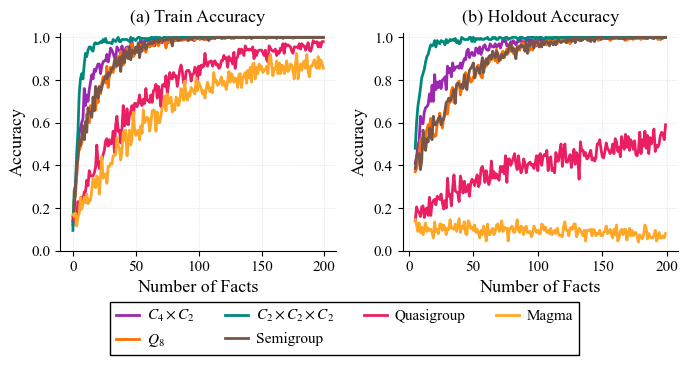

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.2))

for (g, name), color in zip(structures, colors):
    ax1.plot(train_scores[name], label=name, color=color, linewidth=2.0)
    ax2.plot(*holdout_scores[name], label=name, color=color, linewidth=2.0)

ax1.set_ylabel('Accuracy', fontsize=13)
ax1.set_xlabel('Number of Facts', fontsize=13)
ax1.set_ylim([0, 1.02])
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('(a) Train Accuracy', fontsize=13, pad=8)
ax1.tick_params(labelsize=11)

ax2.set_ylabel('Accuracy', fontsize=13)
ax2.set_xlabel('Number of Facts', fontsize=13)
ax2.set_ylim([0, 1.02])
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('(b) Holdout Accuracy', fontsize=13, pad=8)
ax2.tick_params(labelsize=11)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=True,
           borderaxespad=0.5, handlelength=1.5, handletextpad=0.5,
           bbox_to_anchor=(0.5, -0.15), edgecolor='black', fancybox=False, fontsize=11)

plt.tight_layout(pad=1.0)
plt.subplots_adjust(bottom=0.2)
# plt.savefig('order8_train_holdout.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
# sample_distribution_batch(test_task, batch_size=3, k_shots=11, distribution='cancel')

## Model Performance on Targeted Distributions (Figure 3c / Table 2)

In [10]:
def distribution_accuracy(model, task, distribution, **kwargs):
    """Compute model accuracy on a targeted distribution for k=5-200."""
    device = next(model.parameters()).device
    accuracies = []
    for shots in tqdm(range(5, 201)):
        with torch.no_grad():
            batch = sample_distribution_batch(task, k_shots=shots, distribution=distribution, **kwargs)
            outputs = model(batch['inputs'].to(device))
            targets = batch['targets']
            if not isinstance(outputs, torch.Tensor):
                outputs = outputs[0]
            predictions = outputs.argmax(2).cpu()
            accuracy = (predictions[:,-1] == targets[:,-1]).float().mean(0).item()
        accuracies.append((shots, accuracy))
    return list(zip(*accuracies))

copy_results      = distribution_accuracy(model, test_task, 'copy',      batch_size=400)
commute_results   = distribution_accuracy(model, test_task, 'commute',   batch_size=400)
identity_results  = distribution_accuracy(model, test_task, 'identity',  batch_size=400)
cancel_results    = distribution_accuracy(model, test_task, 'cancel',    batch_size=400, include_row_column=False)
associate_results = distribution_accuracy(model, test_task, 'associate', batch_size=400)

  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/196 [00:00<?, ?it/s]

In [11]:
def dict_to_html_table(data_dict, col_names, table_id=None, table_class=None):
    """
    Convert a dictionary of lists to an HTML table.
    Keys become row headers, values become columns.
    """
    id_attr = f' id="{table_id}"' if table_id else ''
    class_attr = f' class="{table_class}"' if table_class else ''

    html = f'<table{id_attr}{class_attr} style="border-collapse: collapse; margin: 10px;">\n'

    max_cols = max(len(v) for v in data_dict.values()) if data_dict else 0
    html += '  <thead>\n    <tr style="background-color: #f2f2f2;">\n'
    html += '      <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Key</th>\n'
    for i in range(max_cols):
        html += f'      <th style="border: 1px solid #ddd; padding: 8px; text-align: center;">{col_names[i]}</th>\n'
    html += '    </tr>\n  </thead>\n'

    html += '  <tbody>\n'
    for key, values in data_dict.items():
        html += '    <tr>\n'
        html += f'      <td style="border: 1px solid #ddd; padding: 8px; font-weight: bold;">{key}</td>\n'
        for val in values:
            html += f'      <td style="border: 1px solid #ddd; padding: 8px; text-align: center;">{round(val, 2)}</td>\n'
        for _ in range(max_cols - len(values)):
            html += '      <td style="border: 1px solid #ddd; padding: 8px;"></td>\n'
        html += '    </tr>\n'
    html += '  </tbody>\n</table>'
    return html

def subset_dict_lists(dict_of_lists, indices):
    """Extract specified indices from all lists in a dictionary."""
    result = {}
    for key, lst in dict_of_lists.items():
        result[key] = [lst[i] for i in indices if i < len(lst)]
    return result

In [12]:
# Figure 3c: k=50 and k=100 (results[1] is accuracy list starting from k=5)
all_results = {
    'copy':      copy_results[1],
    'commute':   commute_results[1],
    'identity':  identity_results[1],
    'associate': associate_results[1],
    'cancel':    cancel_results[1],
}

idx_select = [x-5 for x in [50, 100]]  # k=50 and k=100
HTML(dict_to_html_table(subset_dict_lists(all_results, idx_select), [50, 100]))

Key,50,100
copy,1.0,1.0
commute,1.0,0.99
identity,1.0,1.0
associate,0.55,0.5
cancel,0.96,0.9


In [13]:
# Table 2: extended k values
idx_select = [x - 5 for x in [5, 10, 25, 50, 75, 100, 150, 200]]
HTML(dict_to_html_table(subset_dict_lists(all_results, idx_select), [5, 10, 25, 50, 75, 100, 150, 200]))

Key,5,10,25,50,75,100,150,200
copy,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
commute,1.0,0.99,0.99,1.0,0.99,0.99,1.0,1.0
identity,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.99
associate,0.6,0.64,0.63,0.55,0.61,0.5,0.5,0.38
cancel,0.59,0.76,0.94,0.96,0.92,0.9,0.81,0.8


## Quasigroup Cancellation Performance (Figure 12)

In [14]:
C8   = CyclicGroup(8)
Dih4 = DihedralGroup(4)
QQ8 = Quasigroup(8)

cancel_colors = {
    'C8':         '#2E7D32',
    'D4':         '#1976D2',
    'Quasigroup': '#E91E63',
}
cancel_structures = [(C8, 'C8'), (Dih4, 'D4'), (QQ8, 'Quasigroup')]
quasigroup_cancel_results = {}

for group, name in cancel_structures:
    accs = []
    shots = []
    for K in tqdm(range(5, 201, 5)):
        batch = sample_distribution_batch(test_task, 200, fixed_groups=[group], 
                                        k_shots=K, distribution='cancel', include_row_column=False)
        with torch.no_grad():
            outputs = model(batch['inputs'].to(model.device))
            if not isinstance(outputs, torch.Tensor):
                outputs = outputs[0]
            predictions = outputs.argmax(2).cpu()
            mask = batch['inputs'][0] == test_task.predict_token_id
            accuracy = (predictions[:,mask] == batch['targets'][:,mask]).float().mean(0)
        accs.append(float(accuracy[-1]))
        shots.append(K)
    quasigroup_cancel_results[name] = {'shots': shots, 'accs': accs}

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

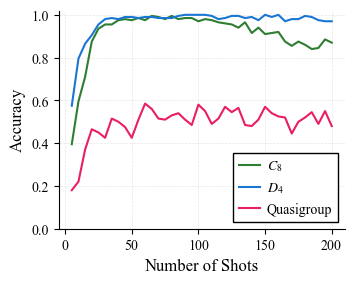

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.8))

for group, name in cancel_structures:
    label = fr'$C_8$' if name == 'C8' else (fr'$D_4$' if name == 'D4' else name)
    ax.plot(quasigroup_cancel_results[name]['shots'], quasigroup_cancel_results[name]['accs'],
            label=label, color=cancel_colors[name], linewidth=1.5)

ax.set_ylabel('Accuracy')
ax.set_xlabel('Number of Shots')
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best', frameon=True, borderaxespad=0.5,
          handlelength=1.5, handletextpad=0.5)

plt.tight_layout(pad=0.5)
# plt.savefig('quasigroup_cancel_new.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Save / Load Results

In [16]:
torch.save({
    'heldout_scores':             heldout_scores,
    'train_scores':               train_scores,
    'holdout_scores':             holdout_scores,
    'copy_results':               copy_results,
    'commute_results':            commute_results,
    'identity_results':           identity_results,
    'cancel_results':             cancel_results,
    'associate_results':          associate_results,
    'quasigroup_cancel_results':  quasigroup_cancel_results,
}, 'behavioral_performance_results.pt')

In [17]:
# Load previously saved results
results = torch.load('behavioral_performance_results.pt')
heldout_scores            = results['heldout_scores']
train_scores              = results['train_scores']
holdout_scores            = results['holdout_scores']
copy_results              = results['copy_results']
commute_results           = results['commute_results']
identity_results          = results['identity_results']
cancel_results            = results['cancel_results']
associate_results         = results['associate_results']
quasigroup_cancel_results = results['quasigroup_cancel_results']

/tmp/ipykernel_1506125/514632905.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load('behavioral_performance_results.pt')
